<a href="https://colab.research.google.com/github/shravani08112000-cyber/filter-/blob/master/EDA_Datapreprocessing_assing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import libraries
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns
df = sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df_original = df.copy()

In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
numrical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

In [ ]:
print("Numerical Columns:")
print(numrical_cols)
print("Categorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')
Categorical Columns:
Index(['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive'], dtype='object')


In [ ]:
from pandas._libs import missing
#delete missing values
#count missing values
missing_values = df.isnull().sum()
missing_count = missing_values[missing_values > 0]
missing_percentage = (missing_count / len(df)) * 100
missing_percentage = missing_percentage.round(2)
#create a DataFrame to display missing values and their percentages
missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing Count': missing_count.values,
    'Missing Percentage': missing_percentage.values
})
print(missing_df)

        Column  Missing Count  Missing Percentage
0          age            177               19.87
1     embarked              2                0.22
2         deck            688               77.22
3  embark_town              2                0.22


In [ ]:
missing_df

,Column,Missing Count,Missing Percentage
0,age,177,19.87
1,embarked,2,0.22
2,deck,688,77.22
3,embark_town,2,0.22


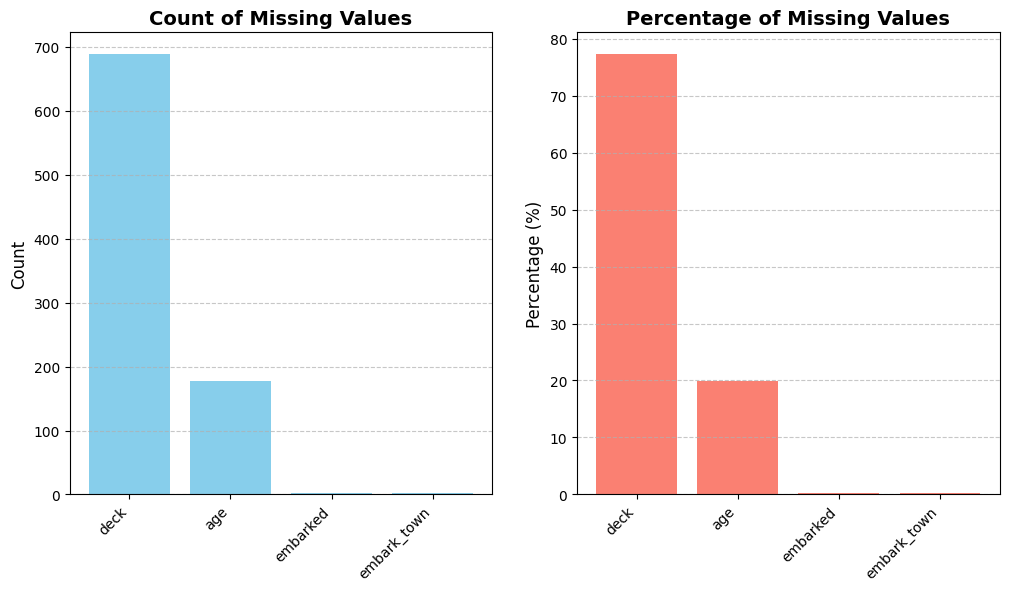

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

missing_count = df.isnull().sum().sort_values(ascending=False)
missing_count = missing_count[missing_count > 0]

axes[0].bar(range(len(missing_count)), missing_count.values,color='skyblue')
axes[0].set_xticks(range(len(missing_count)))
axes[0].set_xticklabels(missing_count.index, rotation=45, ha='right')
axes[0].set_title('Count of Missing Values', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
# Calculate percentage of missing values
missing_percentage = (missing_count / len(df)) * 100
axes[1].bar(range(len(missing_percentage)), missing_percentage.values, color='salmon')
axes[1].set_xticks(range(len(missing_percentage)))
axes[1].set_xticklabels(missing_percentage.index, rotation=45, ha='right')
axes[1].set_title('Percentage of Missing Values', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

In [ ]:
#identify the columns to drop
threshold =0.7
missing_ratio = df.isnull().sum()/ len(df)
cols_to_drop = missing_ratio[missing_ratio >threshold].index.tolist()

print(f"column to drop:{cols_to_drop}")
print(f"Jsutification: {threshold*100:0f}% missing values")
#drop columns
df_clean = df.drop(columns=cols_to_drop)
print(f"\n shape before:{df.shape}")
print(f"shape after: {df_clean.shape}")


column to drop:['deck']
Jsutification: 70.000000% missing values

 shape before:(891, 15)
shape after: (891, 14)


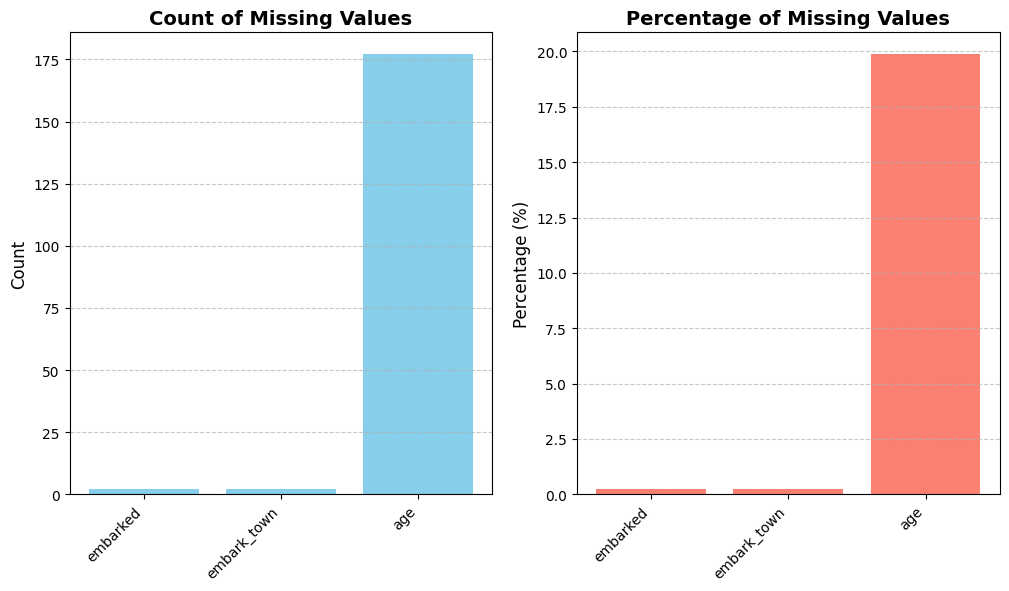

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

missing_count = df_clean.isnull().sum().sort_values(ascending=True)
missing_count = missing_count[missing_count >0]

axes[0].bar(range(len(missing_count)), missing_count.values,color='skyblue')
axes[0].set_xticks(range(len(missing_count)))
axes[0].set_xticklabels(missing_count.index, rotation=45, ha='right')
axes[0].set_title('Count of Missing Values', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
# Calculate percentage of missing values
missing_percentage = (missing_count / len(df_clean)) * 100.
axes[1].bar(range(len(missing_percentage)), missing_percentage.values, color='salmon')
axes[1].set_xticks(range(len(missing_percentage)))
axes[1].set_xticklabels(missing_percentage.index, rotation=45, ha='right')
axes[1].set_title('Percentage of Missing Values', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)


In [ ]:
if 'embark_town' in df_clean.columns:
  print(f"\n embarked_town_missing:{df_clean['embark_town'].isnull().sum()}")
  print(df_clean['embark_town'].value_counts())

  mode_value = df_clean['embark_town'].mode()[0]
  print(mode_value)

  #fill missing values with mode
  df_clean['embark_town'] = df_clean['embark_town'].fillna(mode_value)
  print(f"\n missing  after imputation: {df_clean['embark_town'].isnull().sum()}")


 embarked_town_missing:2
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64
Southampton

 missing  after imputation: 0


In [ ]:
df_clean.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [ ]:
print(f"Missing 'embarked' values before imputation: {df_clean['embarked'].isnull().sum()}")
mode_embarked = df_clean['embarked'].mode()[0]
print(f"Mode of 'embarked' column: {mode_embarked}")

print(f"Missing 'embarked' values after imputation: {df_clean['embarked'].isnull().sum()}")

print('Remaining missing values in df_clean:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing 'embarked' values before imputation: 2
Mode of 'embarked' column: S
Missing 'embarked' values after imputation: 2
Remaining missing values in df_clean:
age         177
embarked      2
dtype: int64


In [ ]:
print(f"Missing 'embark_town' values before imputation: {df_clean['embark_town'].isnull().sum()}")
mode_embark_town = df_clean['embark_town'].mode()[0]
print(f"Mode of 'embark_town' column: {mode_embark_town}")
print(f"Missing 'embark_town' values after imputation: {df_clean['embark_town'].isnull().sum()}")

Missing 'embark_town' values before imputation: 0
Mode of 'embark_town' column: Southampton
Missing 'embark_town' values after imputation: 0


In [ ]:
print(f"Missing 'age' values before imputation: {df_clean['age'].isnull().sum()}")
median_age = df_clean['age'].median()
print(f"Median age: {median_age}")

print(f"Missing 'age' values after imputation: {df_clean['age'].isnull().sum()}")

Missing 'age' values before imputation: 177
Median age: 28.0
Missing 'age' values after imputation: 177
